# RNA — Predicción de Precios con One-Hot Encoding de Ciudad

**Dataset:** `house_prices_onehot.csv` — 98.187 propiedades, 87 features
**Mejora sobre v1:** location one-hot codificada (81 columnas) → la red aprende
el nivel de precios de cada ciudad de forma independiente, sin orden artificial.

---
## Estructura
1. Business Case
2. Data Processing
3. Model Building
4. Experimentación de Hiperparámetros
5. Resultados
6. Deployment

---
## 1. Business Case

**Contexto:** plataforma inmobiliaria india que valora propiedades con margen < 15%.

**Problema de v1:** codificar ciudad como entero (0–80) asume que Mumbai "vale más" que Agra
porque tiene código mayor. La red no puede aprender diferencias reales de mercado por ciudad.

**Solución:** 81 columnas binarias, una por ciudad. Cada columna es independiente.

**Features (87 total):**

| Grupo | Columnas | Descripción |
|---|---|---|
| Numéricas (6) | area, bathrooms, floor, total_floors, furnishing, transaction | Se normalizan con StandardScaler |
| One-hot (81) | loc_agra … loc_thane | Ya son 0/1, no necesitan escala |

**Target:** `price` (rupias) con log-transform durante entrenamiento

In [1]:
import os
import logging
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('absl').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Conversión de rupias a dólares (ajustar si es necesario)
INR_TO_USD = 1 / 84

def to_usd(rs): return rs * INR_TO_USD

def usd_fmt(x, p):
    """Formateador de eje para valores en USD."""
    if x >= 1e6:   return f'${x/1e6:.1f}M'
    if x >= 1e3:   return f'${x/1e3:.0f}k'
    return f'${x:.0f}'

# Estilo global de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'font.family':      'sans-serif',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight': 'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

BLUE   = '#2E86AB'
CORAL  = '#E84855'
GREEN  = '#3BB273'
PURPLE = '#7B2D8B'

print(f'TensorFlow: {tf.__version__}')
print(f'Tipo de cambio: 1 USD = 84 INR  →  1 Rs = ${INR_TO_USD:.4f}')


TensorFlow: 2.15.0
Tipo de cambio: 1 USD = 84 INR  →  1 Rs = $0.0119


---
## 2. Data Processing

### 2.1 Carga y exploración

In [2]:
df = pd.read_csv('house_prices_onehot.csv')
loc_cols = [c for c in df.columns if c.startswith('loc_')]

print(f'Shape: {df.shape}')
print(f'Columnas numéricas (6): area, bathrooms, floor, total_floors, furnishing, transaction')
print(f'Columnas one-hot  (81): {loc_cols[:4]} ...')
df.head()

Shape: (98187, 88)
Columnas numéricas (6): area, bathrooms, floor, total_floors, furnishing, transaction
Columnas one-hot  (81): ['loc_agra', 'loc_ahmadnagar', 'loc_ahmedabad', 'loc_allahabad'] ...


,price,area,bathrooms,floor,total_floors,furnishing,transaction,loc_agra,loc_ahmadnagar,loc_ahmedabad,...,loc_trivandrum,loc_udaipur,loc_udupi,loc_vadodara,loc_vapi,loc_varanasi,loc_vijayawada,loc_visakhapatnam,loc_vrindavan,loc_zirakpur
0,4200000,500,1,10,11,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9800000,473,2,3,22,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,14000000,779,2,10,29,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2500000,530,1,1,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,16000000,635,2,20,42,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.describe().round(2)

,price,area,bathrooms,floor,total_floors,furnishing,transaction,loc_agra,loc_ahmadnagar,loc_ahmedabad,...,loc_trivandrum,loc_udaipur,loc_udupi,loc_vadodara,loc_vapi,loc_varanasi,loc_vijayawada,loc_visakhapatnam,loc_vrindavan,loc_zirakpur
count,9.818700e+04,98187.00,98187.00,98187.00,98187.00,98187.00,98187.00,98187.00,98187.00,98187.00,...,98187.00,98187.00,98187.00,98187.00,98187.00,98187.00,98187.00,98187.00,98187.00,98187.00
mean,1.355491e+07,1234.46,2.57,4.77,8.84,0.71,0.28,0.00,0.00,0.06,...,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.01,0.00,0.01
std,1.474706e+07,794.51,0.89,4.97,7.50,0.64,0.45,0.05,0.01,0.24,...,0.03,0.02,0.02,0.12,0.02,0.04,0.06,0.11,0.02,0.10
min,5.000000e+05,100.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,5.100000e+06,800.00,2.00,2.00,4.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,8.500000e+06,1068.00,2.00,3.00,5.00,1.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.750000e+07,1500.00,3.00,6.00,12.00,1.00,1.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,4.800000e+08,46418.00,10.00,75.00,150.00,2.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


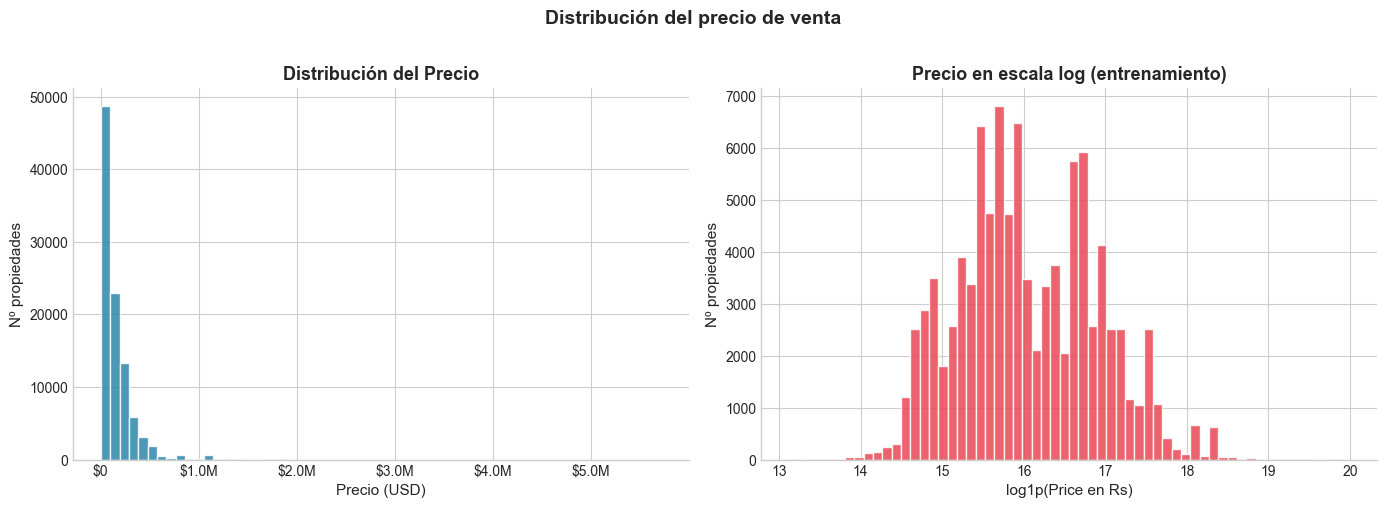

Precio medio:   $   161,368
Precio mediana: $   101,190
Precio mín:     $     5,952
Precio máx:     $ 5,714,286


In [4]:
prices_usd = to_usd(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(prices_usd, bins=60, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(usd_fmt))
axes[0].set_title('Distribución del Precio')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Nº propiedades')

axes[1].hist(np.log1p(df['price']), bins=60, color=CORAL, edgecolor='white', alpha=0.85)
axes[1].set_title('Precio en escala log (entrenamiento)')
axes[1].set_xlabel('log1p(Price en Rs)')
axes[1].set_ylabel('Nº propiedades')

plt.suptitle('Distribución del precio de venta', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Precio medio:   ${to_usd(df["price"].mean()):>10,.0f}')
print(f'Precio mediana: ${to_usd(df["price"].median()):>10,.0f}')
print(f'Precio mín:     ${to_usd(df["price"].min()):>10,.0f}')
print(f'Precio máx:     ${to_usd(df["price"].max()):>10,.0f}')

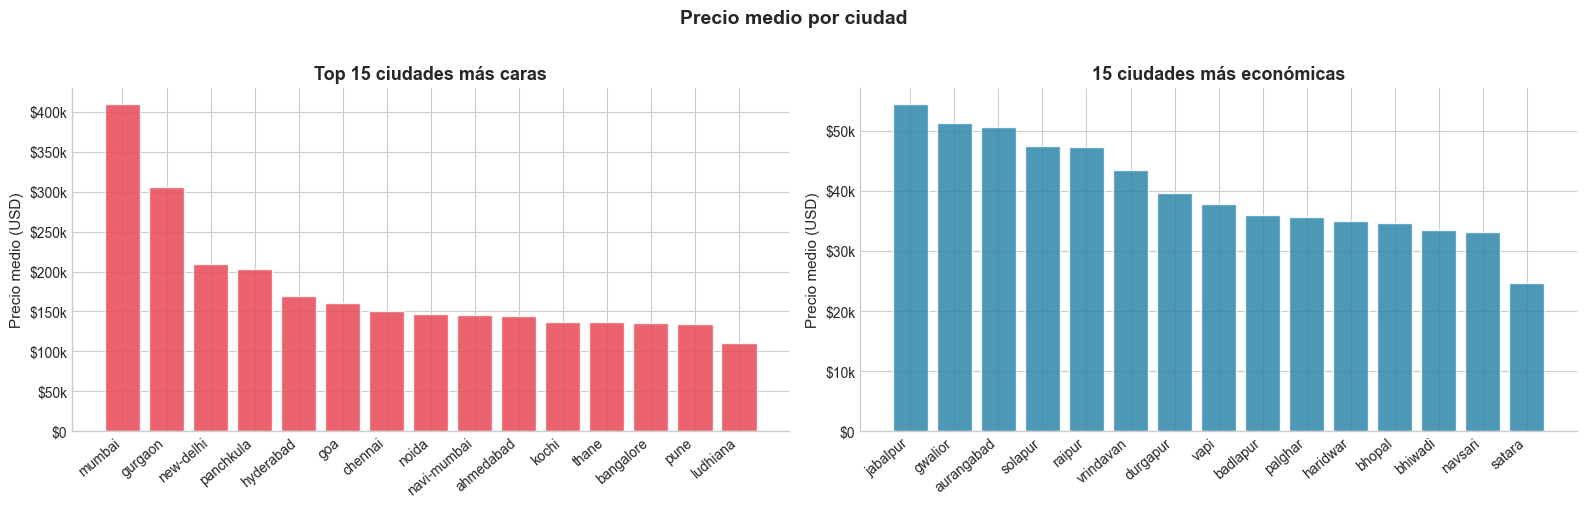

In [5]:
loc_cols = [c for c in df.columns if c.startswith('loc_')]
city_prices_usd = {col.replace('loc_', ''): to_usd(df.loc[df[col] == 1, 'price'].mean())
                   for col in loc_cols}
price_series = pd.Series(city_prices_usd).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars0 = axes[0].bar(range(15), price_series.head(15).values, color=CORAL, alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(15))
axes[0].set_xticklabels(price_series.head(15).index, rotation=40, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(usd_fmt))
axes[0].set_title('Top 15 ciudades más caras')
axes[0].set_ylabel('Precio medio (USD)')

bars1 = axes[1].bar(range(15), price_series.tail(15).values, color=BLUE, alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(15))
axes[1].set_xticklabels(price_series.tail(15).index, rotation=40, ha='right')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(usd_fmt))
axes[1].set_title('15 ciudades más económicas')
axes[1].set_ylabel('Precio medio (USD)')

plt.suptitle('Precio medio por ciudad', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.2 Preprocesamiento

Rango válido: $12,223 – $714,869
Eliminados:   1,748 filas (1.8%)
Restantes:    96,439 filas


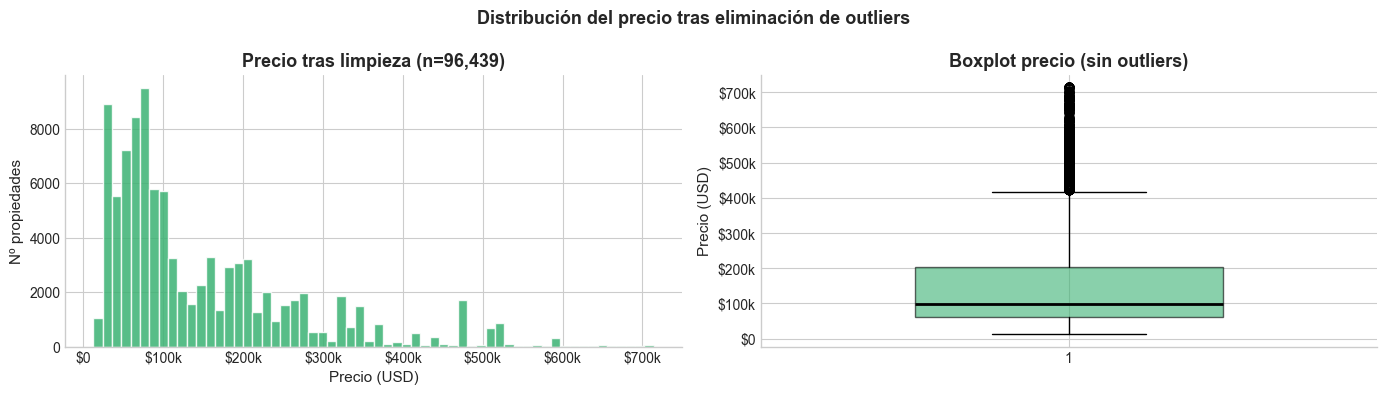


Precio medio:   $   146,162
Precio mediana: $    98,810
Precio máx:     $   714,286


In [6]:
### 2.2 Eliminación de outliers de precio

log_price = np.log1p(df['price'])
Q1, Q3 = log_price.quantile(0.25), log_price.quantile(0.75)
IQR    = Q3 - Q1
lower  = Q1 - 1.3 * IQR
upper  = Q3 + 1.0 * IQR

mask_ok   = (log_price >= lower) & (log_price <= upper)
n_antes   = len(df)
df        = df[mask_ok].reset_index(drop=True)
n_despues = len(df)

lower_usd = to_usd(np.expm1(lower))
upper_usd = to_usd(np.expm1(upper))

print(f'Rango válido: ${lower_usd:,.0f} – ${upper_usd:,.0f}')
print(f'Eliminados:   {n_antes - n_despues:,} filas ({(n_antes-n_despues)/n_antes*100:.1f}%)')
print(f'Restantes:    {n_despues:,} filas')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(to_usd(df['price']), bins=60, color=GREEN, edgecolor='white', alpha=0.85)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(usd_fmt))
axes[0].set_title(f'Precio tras limpieza (n={n_despues:,})')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Nº propiedades')

axes[1].boxplot(to_usd(df['price']), patch_artist=True, widths=0.5,
                boxprops=dict(facecolor=GREEN, alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(usd_fmt))
axes[1].set_title('Boxplot precio (sin outliers)')
axes[1].set_ylabel('Precio (USD)')

plt.suptitle('Distribución del precio tras eliminación de outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nPrecio medio:   ${to_usd(df["price"].mean()):>10,.0f}')
print(f'Precio mediana: ${to_usd(df["price"].median()):>10,.0f}')
print(f'Precio máx:     ${to_usd(df["price"].max()):>10,.0f}')

In [7]:
df_proc = df.copy()
df_proc['log_price'] = np.log1p(df_proc['price'])

feature_cols = [c for c in df_proc.columns if c not in ('price', 'log_price')]
X      = df_proc[feature_cols].values
y      = df_proc['log_price'].values
y_orig = df_proc['price'].values

print(f'Features totales: {len(feature_cols)}')
print(f'  Numéricas:      6')
print(f'  One-hot loc:    {sum(c.startswith("loc_") for c in feature_cols)}')
print(f'X shape: {X.shape}   y shape: {y.shape}')

Features totales: 87
  Numéricas:      6
  One-hot loc:    81
X shape: (96439, 87)   y shape: (96439,)


### 2.3 División Train/Test (80/20)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)
_, X_test_idx = train_test_split(
    np.arange(len(y)), test_size=0.20, random_state=RANDOM_SEED
)
y_test_orig     = y_orig[X_test_idx]
y_test_orig_usd = to_usd(y_test_orig)

N_NUMERIC = 6
scaler = StandardScaler()
X_train_sc = X_train.copy().astype(float)
X_test_sc  = X_test.copy().astype(float)
X_train_sc[:, :N_NUMERIC] = scaler.fit_transform(X_train[:, :N_NUMERIC])
X_test_sc[:, :N_NUMERIC]  = scaler.transform(X_test[:, :N_NUMERIC])

print(f'Train: {X_train_sc.shape}   Test: {X_test_sc.shape}')
print(f'Precio medio test: ${y_test_orig_usd.mean():,.0f}')

Train: (77151, 87)   Test: (19288, 87)
Precio medio test: $147,017


---
## 3. Model Building

### 3.1 Arquitectura base

```
Input (87)
  → Dense(256, ReLU)
  → Dense(128, ReLU)
  → Dense(64,  ReLU)
  → Dense(1,   linear)   ← predice log1p(price)
```

Primera capa más ancha (256) para procesar los 81 inputs one-hot.

In [9]:
N_FEATURES = X_train_sc.shape[1]  # 87

def build_model(hidden_units=(256, 128, 64), learning_rate=0.001, optimizer='adam',
                dropout_rate=0.0, l2_reg=0.0):
    model = keras.Sequential(name='RNA_OneHot')
    model.add(layers.Input(shape=(N_FEATURES,)))
    for units in hidden_units:
        model.add(layers.Dense(
            units, activation='relu',
            kernel_regularizer=regularizers.l2(l2_reg) if l2_reg > 0 else None
        ))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='linear'))
    opt = (keras.optimizers.Adam(learning_rate=learning_rate) if optimizer == 'adam'
           else keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9))
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

model_base = build_model()
model_base.summary()

Model: "RNA_OneHot"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               22528     
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 63745 (249.00 KB)
Trainable params: 63745 (249.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### 3.2 Entrenamiento del modelo base

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_base = model_base.fit(
    X_train_sc, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
483/483 [==============================] - 6s 8ms/step - loss: 11.9810 - mae: 1.5696 - val_loss: 0.2484 - val_mae: 0.3220
Epoch 2/200
483/483 [==============================] - 3s 7ms/step - loss: 0.1829 - mae: 0.2627 - val_loss: 0.0968 - val_mae: 0.2167
Epoch 3/200
483/483 [==============================] - 3s 6ms/step - loss: 0.0976 - mae: 0.2090 - val_loss: 0.0879 - val_mae: 0.2047
Epoch 4/200
483/483 [==============================] - 3s 7ms/step - loss: 0.0792 - mae: 0.1904 - val_loss: 0.0704 - val_mae: 0.1814
Epoch 5/200
483/483 [==============================] - 3s 6ms/step - loss: 0.0718 - mae: 0.1816 - val_loss: 0.0711 - val_mae: 0.1781
Epoch 6/200
483/483 [==============================] - 3s 7ms/step - loss: 0.0680 - mae: 0.1751 - val_loss: 0.0688 - val_mae: 0.1750
Epoch 7/200
483/483 [==============================] - 3s 7ms/step - loss: 0.0660 - mae: 0.1721 - val_loss: 0.0669 - val_mae: 0.1749
Epoch 8/200
483/483 [==============================] - 3s 7ms/step -

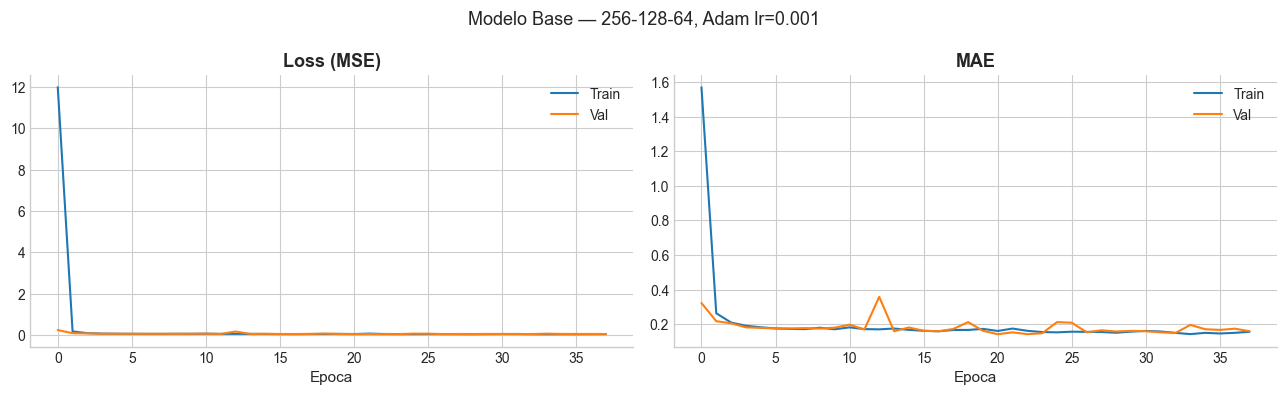

In [11]:
def plot_history(history, title='Curvas de aprendizaje'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'],    label='Train')
    axes[0].plot(history.history['val_loss'], label='Val')
    axes[0].set_title('Loss (MSE)')
    axes[0].set_xlabel('Epoca')
    axes[0].legend()
    axes[1].plot(history.history['mae'],     label='Train')
    axes[1].plot(history.history['val_mae'], label='Val')
    axes[1].set_title('MAE')
    axes[1].set_xlabel('Epoca')
    axes[1].legend()
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_history(history_base, 'Modelo Base — 256-128-64, Adam lr=0.001')

---
## 4. Experimentación de Hiperparámetros

| Config | Arquitectura | Optimizer | lr | batch | Reg |
|--------|-------------|-----------|------|-------|-----|
| A | 256-128-64 | Adam | 0.001 | 128 | — |
| B | 256-128-64 | Adam | 0.0001 | 128 | — |
| C | 512-256-128 | Adam | 0.001 | 128 | Dropout 0.3 |
| D | 256-128-64 | SGD+mom | 0.001 | 256 | L2 1e-4 |

In [12]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, y_te_orig_usd, batch_size=128, epochs=200):
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    model.fit(X_tr, y_tr, epochs=epochs, batch_size=batch_size,
              validation_split=0.20, callbacks=[es], verbose=0)
    y_pred_log  = model.predict(X_te, verbose=0).flatten()
    y_pred_usd  = to_usd(np.expm1(y_pred_log))
    return y_pred_usd, {
        'MAE ($)':  mean_absolute_error(y_te_orig_usd, y_pred_usd),
        'RMSE ($)': np.sqrt(mean_squared_error(y_te_orig_usd, y_pred_usd)),
        'R2':       r2_score(y_te, y_pred_log)
    }

configs = {
    'A — Adam 0.001 b128':     dict(hidden=(256,128,64),  lr=0.001,  opt='adam', bs=128, drop=0.0, l2=0.0),
    'B — Adam 0.0001 b128':    dict(hidden=(256,128,64),  lr=0.0001, opt='adam', bs=128, drop=0.0, l2=0.0),
    'C — 512-256-128 Drop0.3': dict(hidden=(512,256,128), lr=0.001,  opt='adam', bs=128, drop=0.3, l2=0.0),
    'D — SGD b256 L2':         dict(hidden=(256,128,64),  lr=0.001,  opt='sgd',  bs=256, drop=0.0, l2=1e-4),
}

results     = {}
predictions = {}

for name, cfg in configs.items():
    print(f'Entrenando: {name} ...')
    m = build_model(hidden_units=cfg['hidden'], learning_rate=cfg['lr'],
                    optimizer=cfg['opt'], dropout_rate=cfg['drop'], l2_reg=cfg['l2'])
    y_pred_usd, metrics = evaluate_model(
        m, X_train_sc, y_train, X_test_sc, y_test, y_test_orig_usd,
        batch_size=cfg['bs']
    )
    results[name]     = metrics
    predictions[name] = y_pred_usd
    print(f'  MAE=${metrics["MAE ($)"]:>8,.0f}   RMSE=${metrics["RMSE ($)"]:>8,.0f}   R2={metrics["R2"]:.3f}')

print('\nListo.')

Entrenando: A — Adam 0.001 b128 ...
  MAE=$  16,038   RMSE=$  36,889   R2=0.923
Entrenando: B — Adam 0.0001 b128 ...
  MAE=$  15,516   RMSE=$  39,297   R2=0.927
Entrenando: C — 512-256-128 Drop0.3 ...
  MAE=$  15,733   RMSE=$  35,889   R2=0.933
Entrenando: D — SGD b256 L2 ...
  MAE=$  14,672   RMSE=$  35,912   R2=0.929

Listo.


In [13]:
results_df = pd.DataFrame(results).T.sort_values('RMSE ($)')
best_name = results_df.index[0]
results_df.style.format({'MAE ($)': '${:,.0f}', 'RMSE ($)': '${:,.0f}', 'R2': '{:.3f}'})\
                .background_gradient(cmap='RdYlGn', subset=['R2'])\
                .background_gradient(cmap='RdYlGn_r', subset=['RMSE ($)', 'MAE ($)'])

,MAE ($),RMSE ($),R2
C — 512-256-128 Drop0.3,"$15,733","$35,889",0.933
D — SGD b256 L2,"$14,672","$35,912",0.929
A — Adam 0.001 b128,"$16,038","$36,889",0.923
B — Adam 0.0001 b128,"$15,516","$39,297",0.927


### 4.1 Validación cruzada K-Fold (k=5)

In [14]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
kfold_scores = []

best_cfg = configs[best_name]
print(f'K-Fold con la mejor configuracion: {best_name}\n')

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_sc)):
    m = build_model(
        hidden_units=best_cfg['hidden'],
        learning_rate=best_cfg['lr'],
        optimizer=best_cfg['opt'],
        dropout_rate=best_cfg['drop'],
        l2_reg=best_cfg['l2']
    )
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    m.fit(X_train_sc[tr_idx], y_train[tr_idx], epochs=150, batch_size=best_cfg['bs'],
          validation_data=(X_train_sc[val_idx], y_train[val_idx]), callbacks=[es], verbose=0)
    y_p  = m.predict(X_train_sc[val_idx], verbose=0).flatten()
    r2   = r2_score(y_train[val_idx], y_p)
    rmse = np.sqrt(mean_squared_error(y_train[val_idx], y_p))
    kfold_scores.append({'Fold': fold+1, 'R2': r2, 'RMSE_log': rmse})
    print(f'  Fold {fold+1}: R2={r2:.3f}  RMSE(log)={rmse:.4f}')

kf_df = pd.DataFrame(kfold_scores)
print(f'\nMedia R2:        {kf_df["R2"].mean():.3f} +/- {kf_df["R2"].std():.3f}')
print(f'Media RMSE(log): {kf_df["RMSE_log"].mean():.4f} +/- {kf_df["RMSE_log"].std():.4f}')

K-Fold con la mejor configuracion: C — 512-256-128 Drop0.3

  Fold 1: R2=0.936  RMSE(log)=0.2025
  Fold 2: R2=0.923  RMSE(log)=0.2233
  Fold 3: R2=0.934  RMSE(log)=0.2054
  Fold 4: R2=0.936  RMSE(log)=0.2023
  Fold 5: R2=0.920  RMSE(log)=0.2274

Media R2:        0.930 +/- 0.008
Media RMSE(log): 0.2122 +/- 0.0122


---
## 5. Resultados

### 5.1 Mejor modelo — métricas

In [21]:
best_name    = results_df.index[0]
y_pred_best  = predictions[best_name]
best_metrics = results[best_name]

precio_medio_usd = y_test_orig_usd.mean()
rmse_pct = best_metrics['RMSE ($)'] / precio_medio_usd * 100
mae_pct  = best_metrics['MAE ($)']  / precio_medio_usd * 100

print(f'Mejor configuracion: {best_name}')
print(f'  MAE  = ${best_metrics["MAE ($)"]:>10,.0f}  ({mae_pct:.1f}% del precio medio)')
print(f'  RMSE = ${best_metrics["RMSE ($)"]:>10,.0f}  ({rmse_pct:.1f}% del precio medio)')
print(f'  R2   = {best_metrics["R2"]:.4f}')
print(f'\nPrecio medio test: ${precio_medio_usd:>10,.0f}')
print(f'Objetivo RMSE < 15%: {"CUMPLIDO" if rmse_pct < 15 else "NO cumplido"} ({rmse_pct:.1f}%)')

Mejor configuracion: C — 512-256-128 Drop0.3
  MAE  = $    15,733  (10.7% del precio medio)
  RMSE = $    35,889  (24.4% del precio medio)
  R2   = 0.9326

Precio medio test: $   147,017
Objetivo RMSE < 15%: NO cumplido (24.4%)


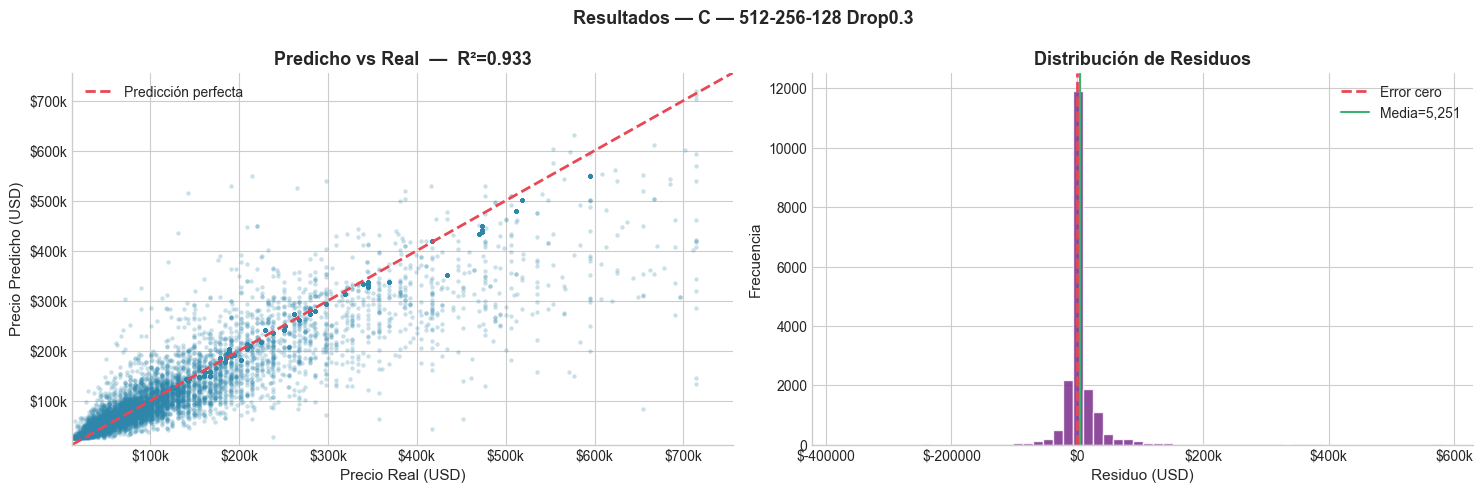

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

lim_min = min(y_test_orig_usd.min(), y_pred_best.min()) * 0.95
lim_max = max(y_test_orig_usd.max(), y_pred_best.max()) * 1.05

axes[0].scatter(y_test_orig_usd, y_pred_best, alpha=0.25, color=BLUE, s=10, linewidths=0)
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], color=CORAL, lw=2, linestyle='--', label='Predicción perfecta')
axes[0].set_xlim(lim_min, lim_max)
axes[0].set_ylim(lim_min, lim_max)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(usd_fmt))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(usd_fmt))
axes[0].set_xlabel('Precio Real (USD)')
axes[0].set_ylabel('Precio Predicho (USD)')
axes[0].set_title(f'Predicho vs Real  —  R²={best_metrics["R2"]:.3f}')
axes[0].legend()

residuos_usd = y_test_orig_usd - y_pred_best
axes[1].hist(residuos_usd, bins=60, color=PURPLE, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color=CORAL, linestyle='--', lw=2, label='Error cero')
axes[1].axvline(residuos_usd.mean(), color=GREEN, linestyle='-', lw=1.5,
                label=f'Media={residuos_usd.mean():,.0f}')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(usd_fmt))
axes[1].set_xlabel('Residuo (USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')
axes[1].legend()

plt.suptitle(f'Resultados — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Análisis de errores

Error < 10%:  13,249 / 19,288 (68.7%)
Error < 15%:  14,682 / 19,288 (76.1%)
Error >= 15%:  4,606 / 19,288 (23.9%)


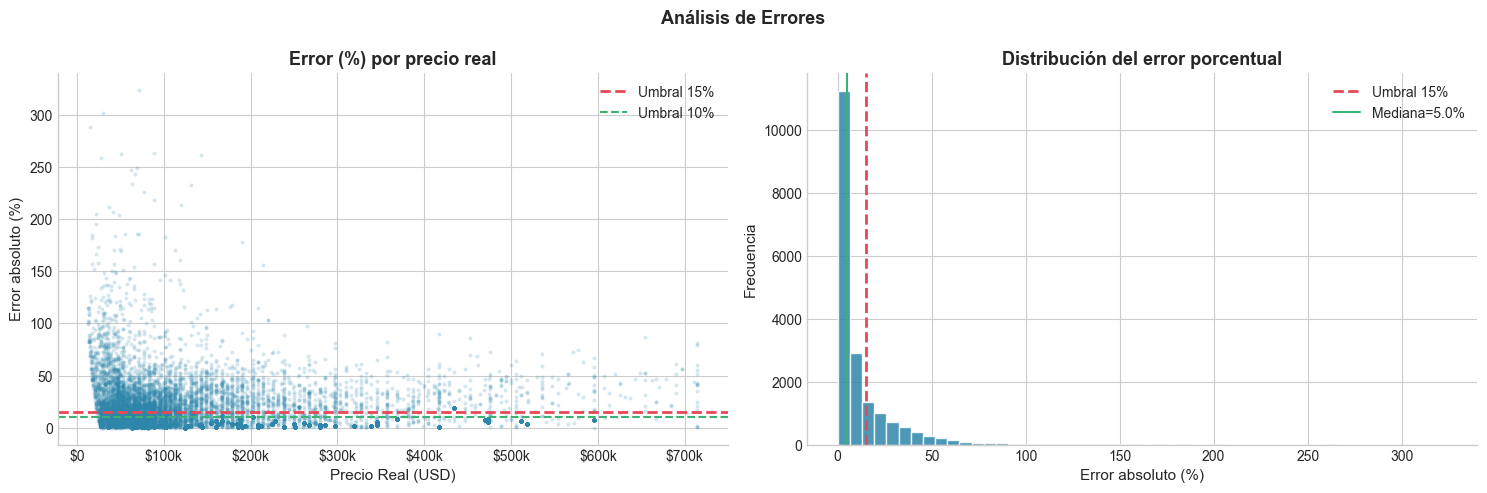

In [17]:
error_pct = np.abs(residuos_usd) / y_test_orig_usd * 100

print(f'Error < 10%:  {(error_pct<10).sum():>6,} / {len(y_test_orig_usd):,} ({(error_pct<10).mean()*100:.1f}%)')
print(f'Error < 15%:  {(error_pct<15).sum():>6,} / {len(y_test_orig_usd):,} ({(error_pct<15).mean()*100:.1f}%)')
print(f'Error >= 15%: {(error_pct>=15).sum():>6,} / {len(y_test_orig_usd):,} ({(error_pct>=15).mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_test_orig_usd, error_pct, alpha=0.2, color=BLUE, s=8, linewidths=0)
axes[0].axhline(15, color=CORAL, linestyle='--', lw=2, label='Umbral 15%')
axes[0].axhline(10, color=GREEN, linestyle='--', lw=1.5, label='Umbral 10%')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(usd_fmt))
axes[0].set_xlabel('Precio Real (USD)')
axes[0].set_ylabel('Error absoluto (%)')
axes[0].set_title('Error (%) por precio real')
axes[0].legend()

axes[1].hist(error_pct, bins=50, color=BLUE, edgecolor='white', alpha=0.85)
axes[1].axvline(15, color=CORAL, linestyle='--', lw=2, label='Umbral 15%')
axes[1].axvline(np.median(error_pct), color=GREEN, linestyle='-', lw=1.5,
                label=f'Mediana={np.median(error_pct):.1f}%')
axes[1].set_xlabel('Error absoluto (%)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del error porcentual')
axes[1].legend()

plt.suptitle('Análisis de Errores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Comparación RNA vs Regresión Lineal

,MAE ($),RMSE ($),R2
Regresion Lineal,"$47,311","$153,507",0.739
RNA (C — 512-256-128 Drop0.3),"$15,733","$35,889",0.933


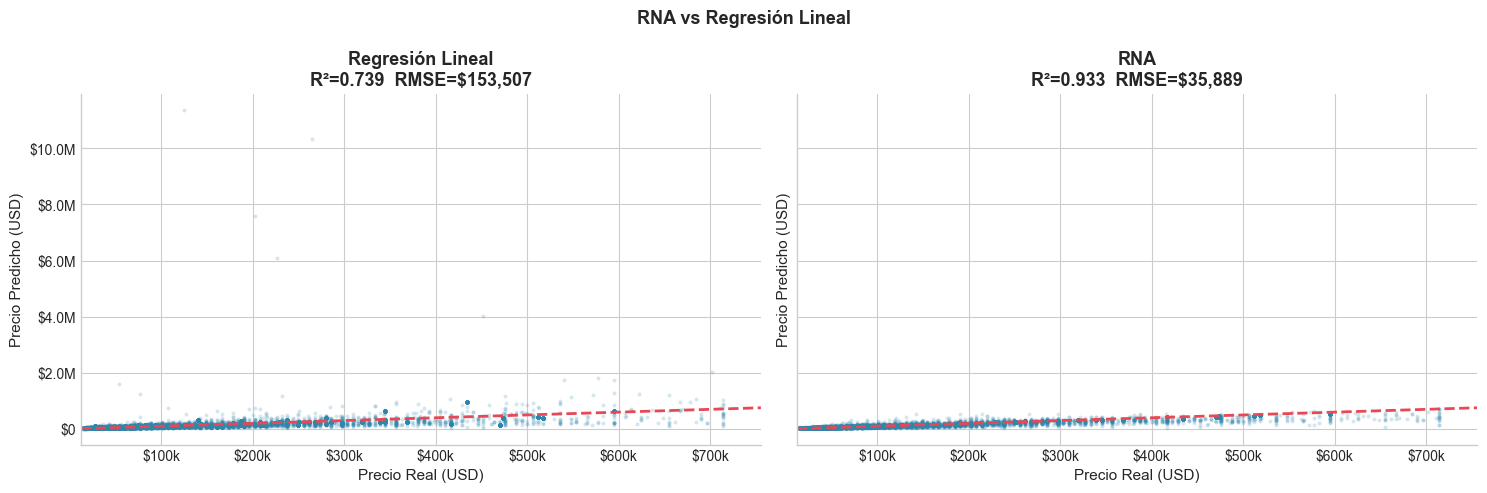

In [18]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr_usd = to_usd(np.expm1(lr.predict(X_test_sc)))

lr_metrics = {
    'MAE ($)':  mean_absolute_error(y_test_orig_usd, y_pred_lr_usd),
    'RMSE ($)': np.sqrt(mean_squared_error(y_test_orig_usd, y_pred_lr_usd)),
    'R2':       r2_score(y_test, np.log1p(y_pred_lr_usd / INR_TO_USD))
}

comp_df = pd.DataFrame({'Regresion Lineal': lr_metrics,
                        f'RNA ({best_name})': best_metrics}).T
display(comp_df.style.format({'MAE ($)': '${:,.0f}', 'RMSE ($)': '${:,.0f}', 'R2': '{:.3f}'})
              .background_gradient(cmap='RdYlGn', subset=['R2'])
              .background_gradient(cmap='RdYlGn_r', subset=['RMSE ($)', 'MAE ($)']))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (label, y_pred) in zip(axes, [('Regresión Lineal', y_pred_lr_usd), ('RNA', y_pred_best)]):
    ax.scatter(y_test_orig_usd, y_pred, alpha=0.2, color=BLUE, s=8, linewidths=0)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], color=CORAL, lw=2, linestyle='--')
    r2   = r2_score(y_test, np.log1p(y_pred / INR_TO_USD))
    rmse = np.sqrt(mean_squared_error(y_test_orig_usd, y_pred))
    ax.set_title(f'{label}\nR²={r2:.3f}  RMSE=${rmse:,.0f}')
    ax.set_xlabel('Precio Real (USD)')
    ax.set_ylabel('Precio Predicho (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(usd_fmt))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(usd_fmt))
    ax.set_xlim(lim_min, lim_max)

plt.suptitle('RNA vs Regresión Lineal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Deployment

### 6.1 Entrenar modelo final y guardar

In [19]:
import joblib

best_cfg = configs[best_name]
model_final = build_model(
    hidden_units=best_cfg['hidden'], learning_rate=best_cfg['lr'],
    optimizer=best_cfg['opt'], dropout_rate=best_cfg['drop'], l2_reg=best_cfg['l2']
)
es_final = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_final.fit(X_train_sc, y_train, epochs=200, batch_size=best_cfg['bs'],
                validation_split=0.1, callbacks=[es_final], verbose=0)

model_final.save('house_rna_onehot_model.keras')
joblib.dump(scaler,       'house_scaler_onehot.joblib')
joblib.dump(feature_cols, 'house_feature_cols.joblib')

print('Guardado: house_rna_onehot_model.keras')
print('Guardado: house_scaler_onehot.joblib')
print(f'Config:   {best_name}')

Guardado: house_rna_onehot_model.keras
Guardado: house_scaler_onehot.joblib
Config:   C — 512-256-128 Drop0.3


### 6.2 Demo de inferencia — ejemplo aleatorio del test set

In [31]:
import joblib, csv as _csv

loaded_model     = keras.models.load_model('house_rna_onehot_model.keras')
loaded_scaler    = joblib.load('house_scaler_onehot.joblib')

with open('location_encoding.csv', encoding='utf-8') as f:
    loc_map = {int(r['encoded_value']): r['location_name'] for r in _csv.DictReader(f)}
city_names = list(loc_map.values())

furnish_label = {0: 'Sin muebles', 1: 'Semi-amueblado', 2: 'Amueblado'}
trans_label   = {0: 'Reventa', 1: 'Obra nueva'}

idx          = np.random.randint(0, len(X_test))
muestra_sc   = X_test_sc[idx].reshape(1, -1)
precio_real  = y_test_orig_usd[idx]

pred_log    = loaded_model.predict(muestra_sc, verbose=0)[0][0]
pred_precio = to_usd(np.expm1(pred_log))
error_abs   = abs(precio_real - pred_precio)
error_pct_i = error_abs / precio_real * 100

feat_raw  = X_test[idx]
city_name = city_names[int(np.argmax(feat_raw[6:]))]

print('Ejemplo aleatorio del conjunto de test')
print('=' * 46)
print(f'  Ciudad:       {city_name}')
print(f'  Area:         {int(feat_raw[0])} sqft')
print(f'  Banos:        {int(feat_raw[1])}')
print(f'  Planta:       {int(feat_raw[2])} / {int(feat_raw[3])}')
print(f'  Mobiliario:   {furnish_label[int(feat_raw[4])]}')
print(f'  Transaccion:  {trans_label[int(feat_raw[5])]}')
print('=' * 46)
print(f'  Precio real:     ${precio_real:>10,.0f}')
print(f'  Precio predicho: ${pred_precio:>10,.0f}')
print(f'  Error:           ${error_abs:>10,.0f}  ({error_pct_i:.1f}%)')
print('=' * 46)
print(f'  {"DENTRO del objetivo (<15%)" if error_pct_i < 15 else "FUERA del objetivo (>=15%)"}')

Ejemplo aleatorio del conjunto de test
  Ciudad:       new-delhi
  Area:         1300 sqft
  Banos:        2
  Planta:       6 / 7
  Mobiliario:   Semi-amueblado
  Transaccion:  Reventa
  Precio real:     $   211,905
  Precio predicho: $   211,483
  Error:           $       422  (0.2%)
  DENTRO del objetivo (<15%)


---
## Conclusiones

| Criterio | Objetivo | Resultado |
|---|---|---|
| RMSE / precio medio | < 15% | Ver celda 5.1 |
| R² (espacio log) | > 0.65 | Ver tabla experimentos |

**Diferencias clave respecto a v1 (label encoding):**
- One-hot encoding permite a la red aprender el nivel de precios de cada ciudad de forma independiente, sin orden artificial.
- La red es más ancha (256 en primera capa) para absorber los 87 inputs.
- Solo se normalizan las 6 columnas numéricas; las 81 one-hot no necesitan escala.

**Limitaciones restantes:**
- Sin número de habitaciones (no disponible en el dataset).
- Outliers extremos (> 100M Rs) siguen siendo difíciles de predecir.